# Figures 3 and 4 - statistical testing for condition differences

This notebook contains the code and analyses for Figures 3 and 4 in the paper.

The code was implemented mostly using the MNE-Python package, with sections adapted from the [MNE Permutation F-test on sensor data with 1D cluster level](https://mne.tools/stable/auto_examples/stats/cluster_stats_evoked.html) tutorial and the [MNE Spatiotemporal permutation F-test on full sensor data](https://mne.tools/stable/auto_tutorials/stats-sensor-space/75_cluster_ftest_spatiotemporal.html#tut-cluster-spatiotemporal-sensors) tutorial. 

## Setup

In [1]:
%matplotlib inline
# %matplotlib qt  # uncomment for interactive plots

import pathlib
import numpy as np
import matplotlib.pyplot as plt
import scipy
import mne

mne.set_log_level('WARNING')
print(f'MNE version: {mne.__version__}')

MNE version: 0.1.0.dev18586+g806b593c4


In [2]:
# ─── USER-SPECIFIC SETTINGS ───────────────────────────────────────────────────────────

# comment out/change based on user
# Bianca dir
ROOT_DIR = pathlib.Path('/Users/bianca/502b_MEG/wordoddball')

# --- PATH AND TASK SETTINGS ----

DERIV_DIR    = pathlib.Path(f'{ROOT_DIR}/data/wordoddball/bids/derivatives/analysis__2/sub-002/ses-01/meg')

SUBJECT      = 'sub-002'
SESSION      = 'ses-01'
TASK         = 'wordoddball'

epo_file = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_proc-clean_epo.fif'

STANDARD_COND = 'standard'
DEVIANT_COND  = 'deviant'

evoked_fif = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_ave.fif'

print(f'Evoked file  : {evoked_fif}')
print(f'File exists  : {evoked_fif.exists()}')


Evoked file  : /Users/bianca/502b_MEG/wordoddball/data/wordoddball/bids/derivatives/analysis__2/sub-002/ses-01/meg/sub-002_ses-01_task-wordoddball_ave.fif
File exists  : True


## Load epochs and create context-matched standard 

In [4]:
# Load epochs file
epochs = mne.read_epochs(epo_file, preload=True).pick('mag', exclude='bads')

std_id = epochs.event_id[STANDARD_COND]
dev_id = epochs.event_id[DEVIANT_COND]

events = epochs.events          # (n_epochs, 3)
event_ids = events[:, 2]           # just the event-ID column

# Walk through the event list and collect the epoch index of each standard
# that directly precedes a deviant.
preceding_std_indices = []
deviant_indices = []

for i, ev_id in enumerate(event_ids):
    if ev_id == dev_id and i > 0:           # found a deviant that isn't the first epoch
        deviant_indices.append(i)
        if event_ids[i - 1] == std_id:      # the epoch immediately before it is a standard
            preceding_std_indices.append(i - 1)
            
print(f'Deviants found          : {(event_ids == dev_id).sum()}')
print(f'Preceding standards found: {len(preceding_std_indices)}')


# Use integer indexing to select only those matched standard epochs + deviant epochs
matched_indices = deviant_indices + preceding_std_indices
epochs_matched = epochs.copy()
epochs_matched = epochs_matched[matched_indices]

# only select Z channels and exclude bad channels
z_names = [ch for ch in epochs_matched.copy().pick('mag', exclude='bads').ch_names
           if ch.endswith(' Z')]

epochs_matched = epochs_matched.pick(z_names)

Deviants found          : 129
Preceding standards found: 129


## Load evoked objects and select Z channels

We're loading the evoked objects saved at the end of notebook 2 (from the provided set of notebooks for MEG data analysis). The evoked objects that were saved were:
- `evoked_std` — standard condition average 
- `evoked_std_matched` - standard condition, preceding-deviant matched 
- `evoked_dev` — deviant condition average 
- `evoked_mmn_matched` — context-matched difference wave (deviant − preceding standard)


In [5]:
all_evoked = mne.read_evokeds(evoked_fif, verbose=False)

evoked_std         = mne.read_evokeds(evoked_fif, condition=STANDARD_COND,                                  verbose=False)
evoked_std_matched = mne.read_evokeds(evoked_fif, condition='standard_onset (preceding-deviant matched)',   verbose=False)
evoked_dev         = mne.read_evokeds(evoked_fif, condition=DEVIANT_COND,                                   verbose=False)
evoked_mmn         = mne.read_evokeds(evoked_fif, condition='MMN (deviant - standard)', verbose=False)
evoked_mmn_matched = mne.read_evokeds(evoked_fif, condition='MMN context-matched (deviant - preceding standard)', verbose=False)

print('Loaded evoked objects:')
for ev in [evoked_std, evoked_std_matched, evoked_dev, evoked_mmn, evoked_mmn_matched]:
    print(f'  {ev.comment:<55s}  nave={ev.nave}  shape={ev.data.shape}')


Loaded evoked objects:
  standard                                                 nave=669  shape=(183, 561)
  standard_onset (preceding-deviant matched)               nave=129  shape=(183, 561)
  deviant                                                  nave=129  shape=(183, 561)
  MMN (deviant - standard)                                 nave=108  shape=(183, 561)
  MMN context-matched (deviant - preceding standard)       nave=64  shape=(183, 561)


In [6]:
# Pick only Z-component mag channels, excluding any marked as bad, to use in subsequent analyses
z_names = [ch for ch in evoked_dev.copy().pick('mag', exclude='bads').ch_names
           if ch.endswith(' Z')]

evoked_std_z = evoked_std.copy().pick_channels(z_names)
evoked_std_matched_z = evoked_std_matched.copy().pick_channels(z_names)
evoked_dev_z = evoked_dev.copy().pick_channels(z_names)
evoked_mmn_z = evoked_mmn.copy().pick_channels(z_names)
evoked_mmn_matched_z = evoked_mmn_matched.copy().pick_channels(z_names)

print(f'Z channels selected: {len(z_names)}')

Z channels selected: 61


## Figure 3 - Spatiotemporal permutation testing

/Users/bianca/502b_MEG/mne-opm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Significant times: [0.305  0.3075 0.31   0.3125 0.315  0.3175 0.32   0.3225 0.325  0.3275
 0.33   0.3325 0.335  0.3375 0.34   0.3425 0.345  0.3475 0.35   0.3525
 0.355  0.3575 0.36   0.3625 0.365  0.3675 0.37   0.3725 0.375  0.3775
 0.38   0.3825 0.385  0.3875 0.39  ]
Significant channels: ['T13 2Z Z', 'T11 32 Z', 'T7 33 Z', 'T9 34 Z', 'C3 37 Z', 'C5 38 Z', 'F11 39 Z', 'C1 3A Z', 'T5 3D Z', 'T1 3E Z', 'T3 3F Z', 'F9 3G Z', 'F7 3H Z']


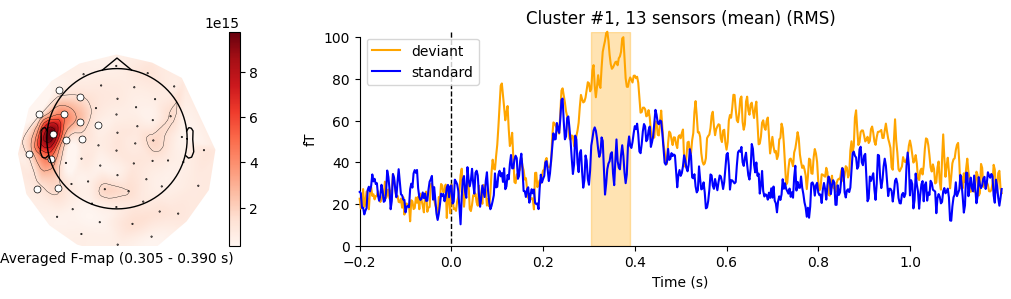

In [7]:
## Spatiotemporal permutation F-test on full sensor data

import scipy.stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds

# Obtain the data as a 3D matrix and transpose it such that
# the dimensions are as expected for the cluster permutation test:
# n_epochs × n_times × n_channels
deviant_epochs = epochs_matched[DEVIANT_COND].get_data(copy = False)
standard_epochs = epochs_matched[STANDARD_COND].get_data(copy = False)
X = [deviant_epochs, standard_epochs]
X = [np.transpose(x, (0, 2, 1)) for x in X]


adjacency, ch_names = find_ch_adjacency(epochs_matched.info, ch_type="mag")

# We are running an F test, so we look at the upper tail
# see also: https://stats.stackexchange.com/a/73993
tail = 1

# We want to set a critical test statistic (here: F), to determine when
# clusters are being formed. Using Scipy's percent point function of the F
# distribution, we can conveniently select a threshold that corresponds to
# alpha level of 0.05.
alpha_cluster_forming = 0.05

# For an F test we need the degrees of freedom for the numerator
# (number of conditions - 1) and the denominator (number of observations
# - number of conditions):
n_conditions = 2
n_observations = len(X[0])
dfn = n_conditions - 1
dfd = n_observations - n_conditions

# Note: we calculate 1 - alpha_cluster_forming to get the critical value
# on the right tail
f_thresh = scipy.stats.f.ppf(1 - alpha_cluster_forming, dfn=dfn, dfd=dfd)

# run the cluster based permutation analysis
cluster_stats = spatio_temporal_cluster_test(
    X,
    n_permutations=1000,
    threshold=f_thresh,
    tail=tail,
    n_jobs=None,
    buffer_size=None,
    adjacency=adjacency,
)
F_obs, clusters, p_values, _ = cluster_stats



# We subselect clusters that we consider significant at an arbitrarily
# picked alpha level: "p_accept".
# NOTE: remember the caveats with respect to "significant" clusters that
# we mentioned in the introduction of this tutorial!
p_accept = 0.05
good_cluster_inds = np.where(p_values < p_accept)[0]

# configure variables for visualization
colors = {"deviant": "orange", "standard": "blue"}

# organize data for plotting
evokeds = {
    "deviant": evoked_dev_z, 
    "standard": evoked_std_matched_z
}

# loop over clusters
for i_clu, clu_idx in enumerate(good_cluster_inds):
    # unpack cluster information, get unique indices
    time_inds, space_inds = np.squeeze(clusters[clu_idx])
    ch_inds = np.unique(space_inds)
    # print(ch_inds)
    time_inds = np.unique(time_inds)

    # get topography for F stat
    f_map = F_obs[time_inds, ...].mean(axis=0)

    # get signals at the sensors contributing to the cluster
    sig_times = epochs_matched.times[time_inds]
    print("Significant times:", sig_times)
    
    # get names of significant channels 
    # print(epochs_matched.ch_names)
    sig_channels = np.array(epochs_matched.ch_names)[ch_inds].tolist()
    print("Significant channels:", sig_channels)

    # create spatial mask
    mask = np.zeros((f_map.shape[0], 1), dtype=bool)
    mask[ch_inds, :] = True

    # initialize figure
    fig, ax_topo = plt.subplots(1, 1, figsize=(10, 3), layout="constrained")

    # plot average test statistic and mark significant sensors
    f_evoked = mne.EvokedArray(f_map[:, np.newaxis], epochs_matched.info, tmin=0)
    f_evoked.plot_topomap(
        times=0,
        mask=mask,
        axes=ax_topo,
        cmap="Reds",
        vlim=(np.min, np.max),
        show=False,
        colorbar=False,
        mask_params=dict(markersize=10),
    )
    image = ax_topo.images[0]

    # remove the title that would otherwise say "0.000 s"
    ax_topo.set_title("")

    # create additional axes (for ERF and colorbar)
    divider = make_axes_locatable(ax_topo)

    # add axes for colorbar
    ax_colorbar = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(image, cax=ax_colorbar)
    ax_topo.set_xlabel(
        "Averaged F-map ({:0.3f} - {:0.3f} s)".format(*sig_times[[0, -1]])
    )

    # add new axis for time courses and plot time courses
    ax_signals = divider.append_axes("right", size="300%", pad=1.2)
    title = f"Cluster #{i_clu + 1}, {len(ch_inds)} sensor"
    if len(ch_inds) > 1:
        title += "s (mean)"
    plot_compare_evokeds(
        evokeds,
        title=title,
        picks=ch_inds,
        axes=ax_signals,
        colors=colors,
        show=False,
        split_legend=True,
        truncate_yaxis="auto",
    )

    # plot temporal cluster extent
    ymin, ymax = ax_signals.get_ylim()
    ax_signals.fill_betweenx(
        (ymin, ymax), sig_times[0], sig_times[-1], color="orange", alpha=0.3
    )

plt.show()


## Figure 4 - Statistical testing in top 5 N400 channels

Top 5 N400 channels (300–450 ms):
  Channel                  Latency     Amplitude
  --------------------  ----------  ------------
  T5 3D Z                  345.0 ms      148.59 fT
  T9 34 Z                  375.0 ms      129.28 fT
  C5 38 Z                  427.5 ms      138.09 fT
  T1 3E Z                  340.0 ms      104.94 fT
  T7 33 Z                  352.5 ms      112.85 fT


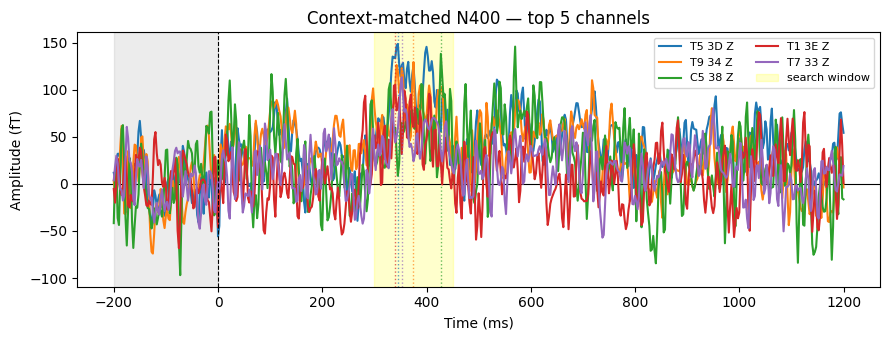

56


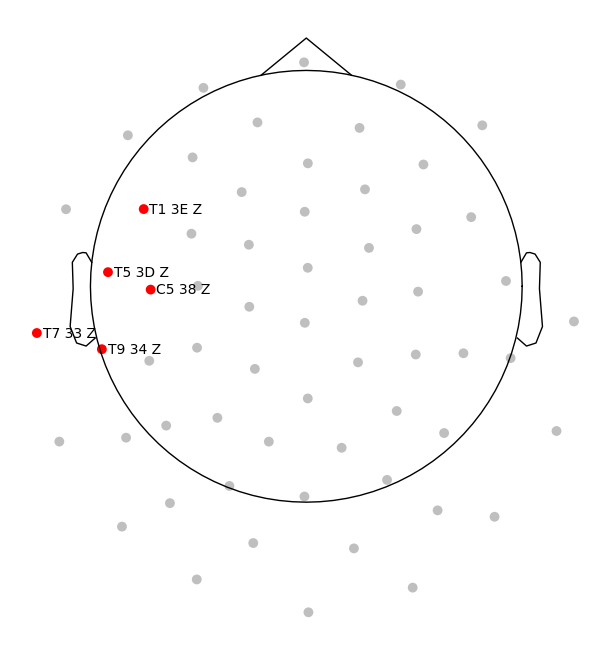

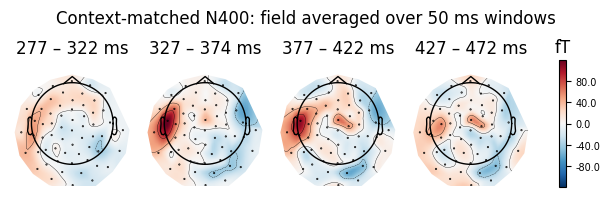

In [30]:
## BEST CHANNEL SELECTION BASED ON RMS FOR CHANNELS IN SIGNIFICANT CLUSTER

from matplotlib.colors import ListedColormap

# ── Rank channels by RMS in the N400 window ───────────────────────────────────
t_idx    = evoked_mmn_z.time_as_index([0.300, 0.450])
# channels_list = ['T13 2Z Z', 'T11 32 Z', 'T7 33 Z', 'T9 34 Z', 'C3 37 Z', 'C5 38 Z', 'F11 39 Z', 'C1 3A Z', 'T5 3D Z', 'T1 3E Z', 'T3 3F Z', 'F9 3G Z', 'F7 3H Z']
evoked_mmn_z_channels = evoked_mmn_z.copy()
evoked_mmn_z_channels = evoked_mmn_z_channels.pick(sig_channels)
window   = evoked_mmn_z_channels.data[:, t_idx[0]:t_idx[1]]
# mean_amp   = np.mean(window, axis=1)
rms      = np.sqrt(np.mean(window ** 2, axis=1))
top5_idx   = np.argsort(rms)[::-1][:5]
top5_names = [evoked_mmn_z_channels.ch_names[i] for i in top5_idx]


# ── Peak latency and amplitude for each top channel ──────────────────────────
print('Top 5 N400 channels (300–450 ms):')
print(f'  {"Channel":<20s}  {"Latency":>10s}  {"Amplitude":>12s}')
print(f'  {"-"*20}  {"-"*10}  {"-"*12}')
results = []
for ch in top5_names:
    ch_evoked = evoked_mmn_z.copy().pick_channels([ch])
    _, lat, amp = ch_evoked.get_peak(
        ch_type='mag',
        tmin=0.300, tmax=0.450,
        mode='abs',
        return_amplitude=True,
    )
    results.append((ch, lat, amp))
    print(f'  {ch:<20s}  {lat*1000:>8.1f} ms  {amp*1e15:>10.2f} fT')

# ── Waveform plot for all 5 channels ─────────────────────────────────────────
times_ms = evoked_mmn_z.times * 1000
fig, ax  = plt.subplots(figsize=(9, 3.5))

ax.axhline(0, color = 'black', lw = 0.8)
colors = plt.cm.tab10.colors
for (ch, lat, amp), color in zip(results, colors):
    ch_idx = evoked_mmn_z.ch_names.index(ch)
    ax.plot(times_ms, evoked_mmn_z.data[ch_idx] * 1e15,
            color=color, lw=1.5, label=ch)
    ax.axvline(lat * 1000, color=color, lw=1, ls=':', alpha=0.7)

ax.axvspan(-200, 0,   color='gray',   alpha=0.15, zorder=0)
ax.axvspan(300,    450, color='yellow', alpha=0.20, zorder=0, label='search window')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (fT)')
ax.set_title('Context-matched N400 — top 5 channels')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()



# fig = evoked_mmn_z.plot_sensors(
#     show_names=top5_names,
#     title='Top 5 N400 channels (300–450 ms)',
#     show=False,
# )
# plt.show()

# set up for nice coloring of sensor map
top5_chs = [evoked_mmn_z.ch_names.index(ch) for ch in top5_names]
non_top5_chs_names = [ch for ch in evoked_mmn_z.ch_names if ch not in top5_names]
non_top5_chs = [evoked_mmn_z.ch_names.index(ch) for ch in non_top5_chs_names]
print(len(non_top5_chs))

my_cmap = ListedColormap([(1, 0, 0, 1), (0.5, 0.5, 0.5, 0.5)])

# Plot the locations of the top 5 N400 channels on a sensor map.
fig = mne.viz.plot_sensors(
    info = epochs_matched.info,
    show_names = top5_names,
    ch_groups = [top5_chs, non_top5_chs], 
    title='Top 5 N400 channels (300–450 ms)',
    cmap = my_cmap,
    linewidth = 0, 
    pointsize = 50,
    show=False,
)
plt.show()



# Topomap averaged over four windows spanning the epoch.
# average= sets the window half-width in seconds (0.050 = ±25 ms around each center).
fig = evoked_mmn_z.plot_topomap(
    times=[0.300, 0.350, 0.400, 0.450],
    ch_type='mag',
    average=0.050,
    time_unit='ms',
    colorbar=True,
    show=False,
)
fig.suptitle('Context-matched N400: field averaged over 50 ms windows', y=1.02)
plt.show()

Significant clusters for T5 3D Z: [[305.0, 307.5, 310.0, 312.5, 315.0, 317.5, 320.0, 322.5, 325.0, 327.5, 330.0, 332.5, 335.0, 337.5, 340.0, 342.5, 345.0, 347.5, 350.0, 352.5, 355.0, 357.5, 360.0, 362.5, 365.0, 367.5, 370.0, 372.5, 375.0, 377.5, 380.0, 382.5, 385.0, 387.5, 390.0], [395.0, 397.5, 400.0, 402.5, 405.0, 407.5, 410.0, 412.5, 415.0, 417.5, 420.0, 422.5, 425.0]]


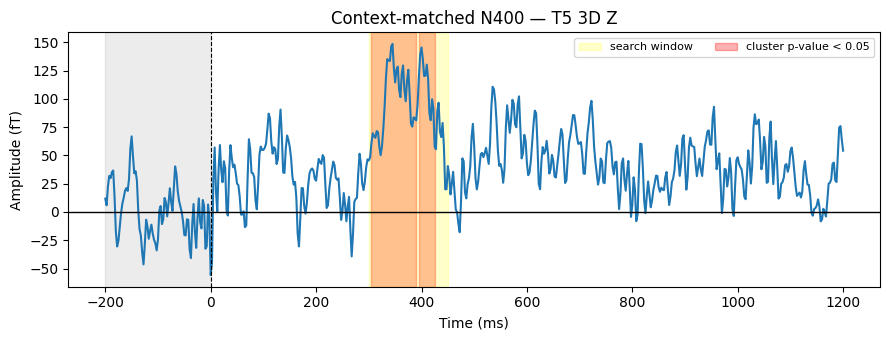

Significant clusters for T9 34 Z: [[337.5, 340.0, 342.5, 345.0, 347.5, 350.0, 352.5, 355.0, 357.5]]


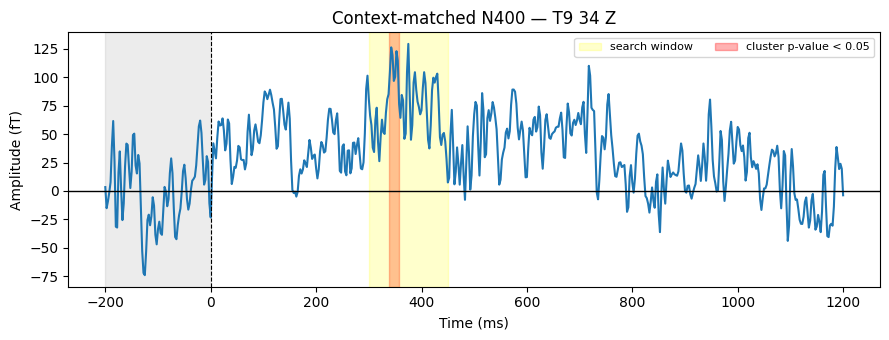

Significant clusters for C5 38 Z: []


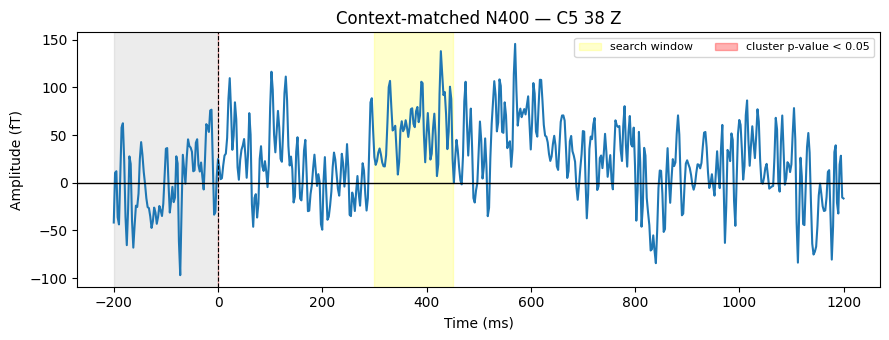

Significant clusters for T1 3E Z: [[335.0, 337.5, 340.0], [357.5, 360.0, 362.5, 365.0, 367.5, 370.0, 372.5, 375.0, 377.5, 380.0], [397.5, 400.0, 402.5, 405.0, 407.5]]


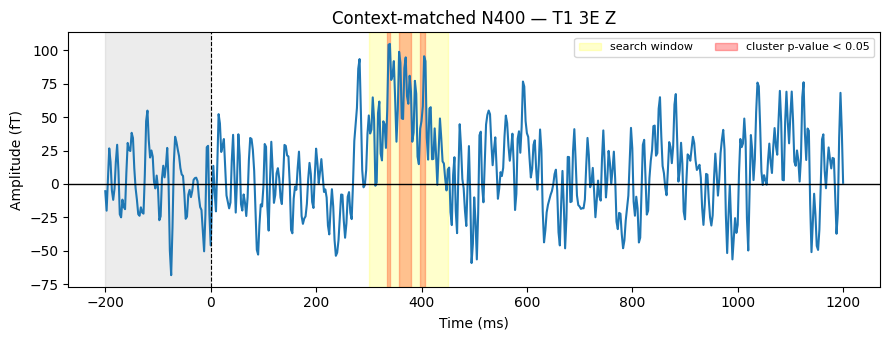

Significant clusters for T7 33 Z: []


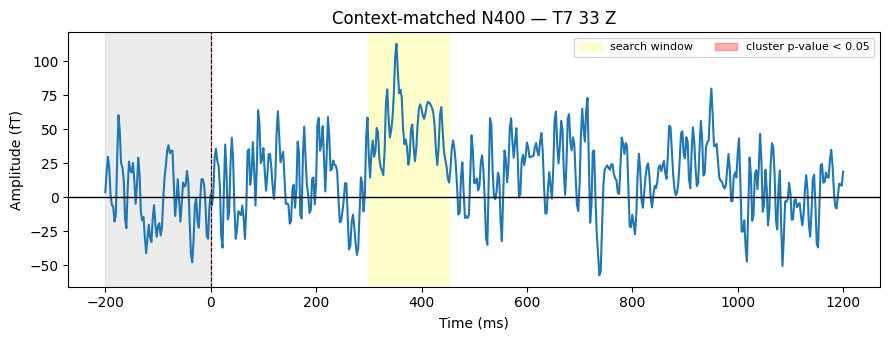

In [9]:
## STATISTICAL TESTING WITHIN CHANNELS OF INTEREST 
# trying to find timepoints with significant difference between conditions for each of the 5 channels of interest
# using cluster level permutation test to correct for multiple comparisons

from mne.stats import permutation_cluster_test

t_idx    = epochs_matched.time_as_index([0.300, 0.450])
times = epochs_matched.times
# print(times)

for ch_name in top5_names:
    
    ch_evoked_mmn = evoked_mmn_z.copy().pick_channels([ch])

    ch_deviant_epochs = epochs_matched[DEVIANT_COND].pick([ch_name])
    ch_deviant = ch_deviant_epochs.get_data()[:, 0, :]
    ch_deviant_N400 = ch_deviant[:, t_idx[0]:t_idx[1]]
    # print(ch_deviant_N400.shape)
    ch_standard_epochs = epochs_matched[STANDARD_COND].pick([ch_name])
    ch_standard = ch_standard_epochs.get_data()[:, 0, :]
    ch_standard_N400 = ch_standard[:, t_idx[0]:t_idx[1]]
    # print(ch_standasrd_N400.shape)
    
    # calculate cluster threshold for p value of 0.05
    pval = 0.05  # arbitrary
    n_conditions = 2
    n_observations = ch_deviant_N400.shape[0]
    dfn = n_conditions - 1  # degrees of freedom numerator
    dfd = n_observations - n_conditions  # degrees of freedom denominator`
    threshold = scipy.stats.f.ppf(1 - pval, dfn=dfn, dfd=dfd)  # F distribution
    # print(threshold)
    # threshold = 6.0
    
    # test is using f-value
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        [ch_deviant_N400, ch_standard_N400],
        n_permutations=1000,
        threshold=threshold,
        tail=1,
        n_jobs=None,
        out_type="indices",
        seed = 876
    )

    # print(clusters)

    sig_clusters = []
    sig_clusters_ms = []
    for i_c, c in enumerate(clusters):
        c = c[0]
        if cluster_p_values[i_c] <= 0.05:
            sig_clusters.append(c)
            cluster_ms = []
            for t in c:
                time_idx = t_idx[0] + t
                time_sec = times[time_idx]
                time_ms = float(time_sec * 1000)
                cluster_ms.append(time_ms)
            sig_clusters_ms.append(cluster_ms)

    # print(sig_clusters)
    print(f"Significant clusters for {ch_name}: {sig_clusters_ms}")


    times_ms = evoked_mmn_z.times * 1000
    fig, ax  = plt.subplots(figsize=(9, 3.5))

    # colors = plt.cm.tab10.colors
    # for (ch, lat, amp), color in zip(results, colors):
    ch_idx = evoked_mmn_z.ch_names.index(ch_name)
    ax.plot(times_ms, evoked_mmn_z.data[ch_idx] * 1e15, lw=1.5)
    # ax.axvline(lat * 1000, color=color, lw=1, ls=':', alpha=0.7)
    
    if sig_clusters_ms:
        for cluster in sig_clusters_ms:
            clusters = ax.axvspan(cluster[0], cluster[-1], color = 'r', alpha = 0.3, zorder = 0, label = "cluster p-value < 0.05")
    else:
        # empty clusters object so that something can still appear on the legend
        clusters = ax.axvspan(0, 0, color = 'r', alpha = 0.3, label = "cluster p-value < 0.05")
    
    ax.axvspan(-200, 0,   color='gray',   alpha=0.15, zorder=0)
    search = ax.axvspan(300,    450, color='yellow', alpha=0.20, zorder=0, label='search window')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.axhline(0, color = 'black', lw = 1)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (fT)')
    ax.set_title(f'Context-matched N400 — {ch_name}')
    ax.legend(handles = [search, clusters], fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

